In [7]:
import pickle
import networkx as nx

GRAPH_PATH = "data/kg_graph.gpickle"

with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

print("Graph loaded.")
print("Nodes:", len(G.nodes()))
print("Edges:", len(G.edges()))

Graph loaded.
Nodes: 4765
Edges: 3118


In [8]:
TARGET = "gradient descent"

if TARGET not in G:
    raise ValueError(f"{TARGET} not found in KG.")

neighbors = list(G.neighbors(TARGET))

print("Concept:", TARGET)
print("Number of related nodes:", len(neighbors))
print(neighbors[:15])   # first few

Concept: gradient descent
Number of related nodes: 8
['convex optimization', 'ze f(a)', 'gradient descent', 'learning rate', 'Neural Networks', 'hill climbing', 'Lipschitz continuity', 'Newton’s method']


In [9]:
sub_nodes = [TARGET] + neighbors
sub = G.subgraph(sub_nodes).copy()

print("Subgraph nodes:", len(sub.nodes()))
print("Subgraph edges:", len(sub.edges()))

# Show neighbors grouped by type
types = {}
for n in neighbors:
    t = G.nodes[n].get("node_type", "unknown")
    types.setdefault(t, []).append(n)

types

Subgraph nodes: 8
Subgraph edges: 12


{'concept': ['convex optimization',
  'ze f(a)',
  'gradient descent',
  'learning rate',
  'Neural Networks',
  'hill climbing',
  'Lipschitz continuity',
  'Newton’s method']}

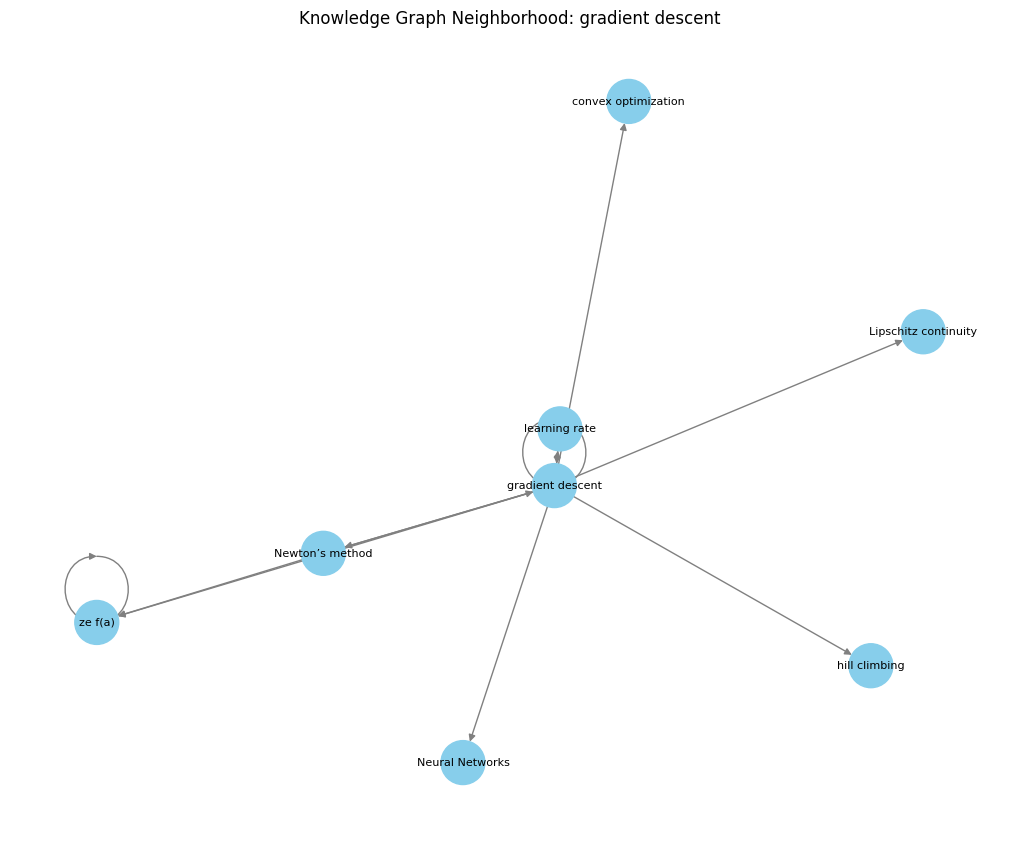

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(sub, seed=42)

# Color by node type
colors = []
for n in sub.nodes():
    t = G.nodes[n].get("node_type", "concept")
    colors.append(
        {"concept":"skyblue", "resource":"lightgreen", "example":"orange"}.get(t, "gray")
    )

nx.draw(
    sub,
    pos,
    with_labels=True,
    node_size=1000,
    font_size=8,
    node_color=colors,
    edge_color="gray"
)

plt.title(f"Knowledge Graph Neighborhood: {TARGET}")
plt.show()